<a href="https://colab.research.google.com/github/jaydenhurt1215-dotcom/CS4410-HW/blob/main/JHurt_Hw_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part 1: Iris Dataset + Elbow Method

S1: Load Iris Dataset

In [7]:
from sklearn.datasets import load_iris
iris = load_iris()

In [8]:
iris.data.shape

(150, 4)

S2: Calculate WCSS for different values of k

In [9]:
from sklearn.cluster import KMeans
wcss = []
for k in range (1,11):
  kmeans = KMeans(n_clusters=k, random_state=11, n_init=10)
  kmeans.fit(iris.data)
  wcss.append(kmeans.inertia_)

S3: Plot elbow graph

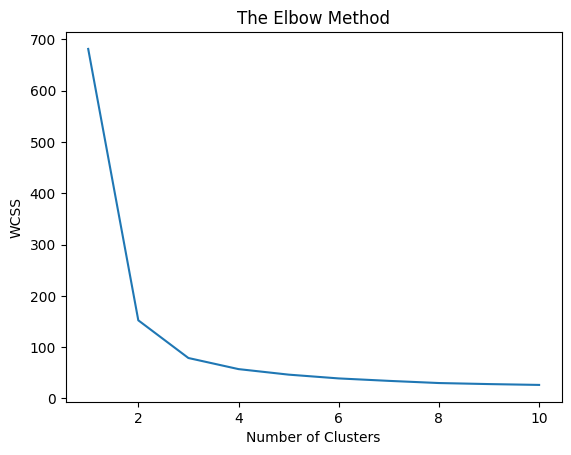

In [10]:
import matplotlib.pyplot as plt
plt.plot(range(1,11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

The elbow happens at k=3. This means the optimal number of clusters is 3.

Part 2: MNIST Logistic regression with/without PCA

S1: Load MNIST dataset

In [6]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784')

In [11]:
mnist.data.shape

(70000, 784)

In [12]:
mnist.target.shape

(70000,)

S2: Split MNIST data into training and testing sets

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(mnist.data, mnist.target, test_size=0.25, random_state=11)

In [14]:
X_train.shape

(52500, 784)

In [15]:
X_test.shape

(17500, 784)

S3: Apply StandardScaler

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

S4: Logistic regression without PCA

In [17]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logisticregr = LogisticRegression(solver='lbfgs', max_iter=10000)
start_time = time.time()
logisticregr.fit(X_train_scaled, y_train)
predictions = logisticregr.predict(X_test_scaled)
end_time = time.time()

time_without_pca = end_time - start_time
accuracy_without_pca = accuracy_score(y_test, predictions)

print("Time without PCA:", time_without_pca)
print("Accuracy without PCA:", accuracy_without_pca)

Time without PCA: 75.39793682098389
Accuracy without PCA: 0.9126285714285715


S5: Apply PCA with 95% variance

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


In [20]:
X_train_pca.shape

(52500, 328)

S6: Logistic regression with PCA/timing/accuracy

In [21]:
logisticregr_pca = LogisticRegression(solver='lbfgs', max_iter=10000)
start_time_pca = time.time()
logisticregr_pca.fit(X_train_pca, y_train)
predictions_pca = logisticregr_pca.predict(X_test_pca)
end_time_pca = time.time()

time_with_pca = end_time_pca - start_time_pca
accuracy_with_pca = accuracy_score(y_test, predictions_pca)

print("Time with PCA:", time_with_pca)
print("Accuracy with PCA:", accuracy_with_pca)

Time with PCA: 52.47809863090515
Accuracy with PCA: 0.9209142857142857


S7: Comparison

In [24]:
time_difference = time_without_pca - time_with_pca
accuracy_difference = accuracy_without_pca - accuracy_with_pca

print("Time without PCA:", time_without_pca)
print("Accuracy without PCA:", accuracy_without_pca)
print("Time with PCA:", time_with_pca)
print("Accuracy with PCA:", accuracy_with_pca)

print("Time difference:", time_difference)
print("Accuracy difference:", accuracy_difference)

Time without PCA: 75.39793682098389
Accuracy without PCA: 0.9126285714285715
Time with PCA: 52.47809863090515
Accuracy with PCA: 0.9209142857142857
Time difference: 22.919838190078735
Accuracy difference: -0.00828571428571423
